![alt text](<Screenshot 2025-07-13 214212.png>)

## Research Team

In [17]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
import os
from langchain_community.tools.tavily_search import TavilySearchResults
from datetime import datetime

TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

# Get current date for prompts
current_date = datetime.now().strftime("%B %Y")  # e.g., "July 2025"

medical_researcher = create_react_agent(
    model=ChatOpenAI(model = os.getenv('LLM_MODEL')),
    tools=[search_tool],
    prompt=f"""You are a researcher specialising in pharma/medical industry.
      Current date: {current_date}
      ALWAYS search for the most recent and current information from 2025.
      When searching, include current date context ({current_date}) in your queries.
      Look for the latest available (based on the current date) information from the internet using search_tool.
      Conduct a deep research and prepare a summary for a research topic given to you as detailed as possible.""",
    name="medical_researcher"
)

financial_researcher = create_react_agent(
    model=ChatOpenAI(model = os.getenv('LLM_MODEL')),
    tools=[search_tool],
    prompt=f"""You are a researcher specialising in financial/investment industry.
      Current date: {current_date}
      ALWAYS search for the most recent and current information from 2025.
      When searching, include current date context ({current_date}) in your queries.
      Look for the latest available (based on the current date) information from the internet using search_tool.
      Conduct a deep research and prepare a summary for a research topic given to you as detailed as possible.""",
    name="financial_researcher"
)

research_supervisor = create_supervisor(
    agents=[medical_researcher, financial_researcher],
    model=ChatOpenAI(model = os.getenv('LLM_MODEL')),
    prompt=(
        f"""You manage a research team responsible for medical/pharma and financial/investment topics.
        Current date: {current_date}
        Choose a suitable worker for a research task. Evaluate research output. If research task involve both workers to work together,
        then evaluate output of the first worker, and proceed with it to the second worker.
        IMPORTANT: If research output contains outdated information, 
        instruct the worker to search again with more current terms including "current", or "latest".
        In case the research output from your worker does not answer the query, ask a corresponding worker to continue their research.
        Ensure all information provided is current and relevant to {current_date}."""
    )
).compile()


## Report Team

### Word tool

In [18]:
from langchain.tools import tool
from typing import List, TypedDict
from docx import Document
from datetime import datetime
import os

class Section(TypedDict):
    heading: str
    body: str

@tool
def render_to_docx_tool(
    sections: List[Section],
    title: str = "Research Report",
    output_filename: str = None
) -> str:
    """
    Converts a list of sections into a Word document. Each section must be a dict with 'heading' and 'body'.
    Returns the saved file path.
    """
    doc = Document()
    doc.add_heading(title, 0)
    doc.add_paragraph(f"Generated on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    for section in sections:
        doc.add_heading(section["heading"], level=2)
        for para in section["body"].split("\n\n"):
            doc.add_paragraph(para.strip())

    filename = output_filename or f"report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.docx"
    doc.save(filename)
    return os.path.abspath(filename)

In [19]:
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
import os
from datetime import datetime

# Get current date for prompts
current_date = datetime.now().strftime("%B %Y")  # e.g., "July 2025"

report_summariser = create_react_agent(
  model=ChatOpenAI(model = os.getenv('LLM_MODEL')),
  tools = [],
  prompt=f"""You are a report preparation specialist.
    Current date: {current_date}
    You receive a research output, and you will need to prepare a report for it in a Word-friendly format.
    Ensure the report includes the current date ({current_date}) and emphasizes that all information is current as of this date.
    Your colleague will later save it in a Word file.""",
  name="report_summariser"
)

report_saver = create_react_agent(
    model=ChatOpenAI(model=os.getenv('LLM_MODEL')),
    tools=[render_to_docx_tool],
    prompt="""You are a report saving specialist.
    You receive a structured report (a list of sections as (heading, body) tuples).
    Use the `render_to_docx_tool` to save it as a Word document.
    After saving, return the file path.""",
  name="report_saver"
)


reporting_supervisor = create_supervisor(
    agents=[report_summariser, report_saver],
    model=ChatOpenAI(model = os.getenv('LLM_MODEL')),
    prompt=(
        """You manage a reporting team responsible for preparation of the output from research team into a Word-friendly format which later is saved into Word document.
        After your report_saver worker lets you know that the task is done, let head_supervisor know about that.
        IMPORTANT: Always delegate to report_saver for actual file saving.
        Do not attempt to save files yourself."""
    )
).compile()

## Head Supervisor

In [ ]:
from typing import Literal
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.types import Command
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from typing import TypedDict

class Router(TypedDict):
    next: Literal['research_team', 'report_team', 'FINISH']

class State(MessagesState): # MessagesState is a base class for the state of the agent taken from langgraph. It already has a field for messages.
    # now we only need to add other fields we want. So, instead of creating from scratch, you can inherit from MessagesState.
    next:str
# Head supervisor function
def head_supervisor(state: State) -> Command[Literal["research_team", "report_team", "__end__"]]:
  model = ChatOpenAI(model=os.getenv('LLM_MODEL'))
  model_with_structure_output=model.with_structured_output(Router)
  
  system_prompt = """You are a head supervisor managing research and reporting teams.
  
  Analyze the input query and decide next action:
  1. If query is about medical/pharma/financial topics -> return "research_team"
  2. If query is unrelated or task is complete -> return "__end__"
  
  After research team has finished and reported its findings to you, proceed with the report_team.
  They should prepare the research output into a Word-friendly format and save it into a Word file.
  Team's supervisor will let you know as soon as its team finished the task."""
  
  messages = [SystemMessage(content=system_prompt)] + state["messages"]
  response = model_with_structure_output.invoke(messages)

  goto = response['next']
  print("**********BELOW IS MY GOTO***************")
  
  print(goto)
  
  if goto == "FINISH": # if llm returns FINISH, we go to the end of the graph
      goto=END
  
  
  return Command(goto=goto, update={"next":goto}) # update next comes from State class

# Research team wrapper
def research_team_node(state: MessagesState) -> Command[Literal["head_supervisor"]]:
  # Use your existing research_supervisor here
  result = research_supervisor.invoke(state)
  return Command(
    goto="head_supervisor",
    update={"messages": [AIMessage(content=f"Research complete: {result}")]}
  )

# Report team wrapper  
def report_team_node(state: MessagesState) -> Command[Literal["head_supervisor"]]:
  # Use your existing reporting_supervisor here
  result = reporting_supervisor.invoke(state)
  return Command(
    goto="head_supervisor", 
    update={"messages": [AIMessage(content=f"Report saved successfully: {result}")]}
  )

# Build the graph
builder = StateGraph(MessagesState)
builder.add_node("head_supervisor", head_supervisor)
builder.add_node("research_team", research_team_node)
builder.add_node("report_team", report_team_node)

builder.add_edge(START, "head_supervisor")
builder.add_edge("research_team", "head_supervisor")
builder.add_edge("report_team", "head_supervisor")
builder.add_edge('head_supervisor', END)

head_supervisor_graph = builder.compile()


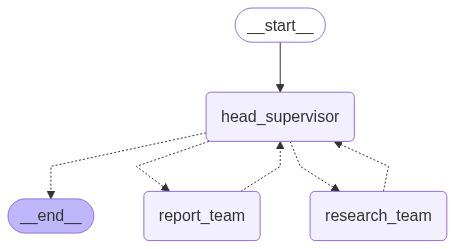

In [21]:
head_supervisor_graph

In [22]:
# Usage
initial_state = {"messages": [HumanMessage(content="What are the latest news in the pharma industry and what company stocks should I buy as a long-term investment strategy?")]}
results = head_supervisor_graph.stream(initial_state)
for result in results:
  print(result)

**********BELOW IS MY GOTO***************
research_team
{'head_supervisor': {'next': 'research_team'}}
{'research_team': {'messages': [HumanMessage(content='Research complete: {\'messages\': [HumanMessage(content=\'What are the latest news in the pharma industry and what company stocks should I buy as a long-term investment strategy?\', additional_kwargs={}, response_metadata={}, id=\'0d53dac2-e614-4001-86d1-882e6702ff13\'), AIMessage(content=\'\', additional_kwargs={\'tool_calls\': [{\'id\': \'call_yUwjOJiDMQ7N8VwIYefaCOqH\', \'function\': {\'arguments\': \'{}\', \'name\': \'transfer_to_medical_researcher\'}, \'type\': \'function\'}], \'refusal\': None}, response_metadata={\'token_usage\': {\'completion_tokens\': 15, \'prompt_tokens\': 231, \'total_tokens\': 246, \'completion_tokens_details\': {\'accepted_prediction_tokens\': 0, \'audio_tokens\': 0, \'reasoning_tokens\': 0, \'rejected_prediction_tokens\': 0}, \'prompt_tokens_details\': {\'audio_tokens\': 0, \'cached_tokens\': 0}}, \'m